<a href="https://colab.research.google.com/github/jay-nakrani/Gold-Performance-Forecasting-A-Machine-Learning-Approach-with-Economic-Data/blob/main/gold_performance_forecasting_weekly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gold Performance Forecasting: A Machine Learning Approach with Economic Data

# Step-1 : *Data collection, analysis and cleaning.*

In [1]:
# To install required packages and import libraries.

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Function to get the data.

def get_data(start):

    """
    To download all the required data from Yahoo finance using yfinance-library.(From 2000 to Today)

    parameters: start= start date of data.

    returns: dictionary of all the downloaded data.
    """

    # To download all the required data from Yahoo finance using yfinance-
    # library.(From 2000 to Today)

    # Gold futures.
    gold = yf.download('GC=F', start=start, auto_adjust=True, progress=False)
    # Treasury yield.(thirty years treasury yield)
    treasury_yield = yf.download('^TYX', start=start, auto_adjust=True, progress=False)
    # USD Index.
    usd_index = yf.download('DX=F', start=start, auto_adjust=True, progress=False)
    # Volatility Index (VIX).
    vix = yf.download('^VIX', start=start, auto_adjust=True, progress=False)
    # Oil futures.
    oil = yf.download('CL=F', start=start, auto_adjust=True, progress=False)
    # Silver futures.
    silver = yf.download('SI=F', start=start, auto_adjust=True, progress=False)

    # To download inflation data (CPI) from federal reserve economic data (FRED).
    cpi_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
    cpi_data = pd.read_csv(cpi_url, index_col=0, parse_dates=True)
    cpi_data.columns = ['CPI']

    # To keep CPI data from year 1999 onwards.
    # # All other data starts from year 2000 but here we need one more year to
    # # calculate anual inflation for year 2000.

    # Convert start to datetime.
    start_date = pd.to_datetime(start)

    # Calculate CPI start date (1 year before start date).
    cpi_start_date = start_date - pd.DateOffset(years=1)
    cpi_start_str = cpi_start_date.strftime('%Y-%m-%d')

    cpi_data = cpi_data[cpi_data.index >= cpi_start_str]

    # To calculate annual inflation rate.
    # For example: march,2024-march,2025; april,2024- april,2025 etc..
    cpi_data['Inflation_Annual'] = cpi_data['CPI'].pct_change(12) * 100  # Year-over-year

    # To keep CPI data from 2000 onwards for analysis as all other data is from
    # year 2000.
    cpi_data_final = cpi_data[cpi_data.index >= start]

    # Resample to daily frequency with forward fill.
    inflation_annual_daily = cpi_data_final['Inflation_Annual'].resample('D').ffill()

    return {'gold': gold,
            'treasury_yield': treasury_yield,
            'usd_index': usd_index,
            'vix': vix,
            'oil': oil,
            'silver': silver,
            'inflation_annual': inflation_annual_daily}

dataframe = get_data(start='2000-01-01')

/tmp/ipython-input-2133866593.py:49: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi_data['Inflation_Annual'] = cpi_data['CPI'].pct_change(12) * 100  # Year-over-year


In [3]:
# To check each downloaded data.
datasets_to_check = {'Gold': dataframe['gold'],
                     'Treasury_yield': dataframe['treasury_yield'],
                     'USD Index': dataframe['usd_index'],
                     'VIX': dataframe['vix'],
                     'US Oil': dataframe['oil'],
                     'Silver': dataframe['silver'],
                     'Inflation Annual Daily': dataframe['inflation_annual']}

for name, data in datasets_to_check.items():
    print(f"\n=== {name.upper()} ===\n")
    print(f"Shape: {data.shape}")
    print(f"Date range: {data.index[0]} to {data.index[-1]}")
    print("\nFirst 3 rows:\n")
    print(data.tail(3))
    print("\nData types:\n")
    print(data.dtypes)
    print(f"Missing values: {data.isnull().sum().sum()}")

    print("-" * 50)
    print("-" * 50)

# To check if all the data is in same range or not.
print("\nDate range comparison")
print("=" * 50)

for name, data in datasets_to_check.items():

    # String representation used to avoid errors.
    start_date = str(data.index[0])[:10]
    end_date = str(data.index[-1])[:10]

    print(f"{name:25} | {start_date} to {end_date} | {len(data):6} records")



=== GOLD ===

Shape: (6360, 5)
Date range: 2000-08-30 00:00:00 to 2026-01-05 00:00:00

First 3 rows:

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2025-12-31  4325.600098  4363.799805  4285.000000  4333.500000    785
2026-01-02  4314.399902  4350.600098  4314.399902  4350.600098    785
2026-01-05  4445.799805  4449.100098  4354.600098  4368.299805  85380

Data types:

Price   Ticker
Close   GC=F      float64
High    GC=F      float64
Low     GC=F      float64
Open    GC=F      float64
Volume  GC=F        int64
dtype: object
Missing values: 0
--------------------------------------------------
--------------------------------------------------

=== TREASURY_YIELD ===

Shape: (6534, 5)
Date range: 2000-01-03 00:00:00 to 2026-01-02 00:00:00

First 3 rows:

Price       Close   High    Low   Open Volume
Ticker       ^TYX   ^TYX 

In [4]:
# function to combine all the data we collected with it's daily close.

def combine_market_data(data):

    """
    This function helps to create a combined dataset of all collected data with-
    it's daily close.

    Parameters: data (dict): A dictionary containing different market datasets.

    Returns: combined_data : A combined dataset with all-features aligned to
    daily frequency.
    """

    # Now we can combine all the datasets into one dataset. we require only close
    # price from each day for further analysis.

    # To initialize combined dataframe.
    combined_data = pd.DataFrame()

    # To extract close prices from each dataset.
    combined_data['Gold_Price'] = data['gold'][('Close', 'GC=F')]
    combined_data['Treasury_yield'] = data['treasury_yield'][('Close', '^TYX')]
    combined_data['USD_Index'] = data['usd_index'][('Close', 'DX=F')]
    combined_data['VIX'] = data['vix'][('Close', '^VIX')]
    combined_data['OIL'] = data['oil'][('Close', 'CL=F')]
    combined_data['SILVER'] = data['silver'][('Close', 'SI=F')]

    # Inflation annual has different end date than other data.
    # Inflation data we get every month but it is for the last month. For example
    # current month is october so we get the inflation data of september in the
    # starting of october. This data don't change daily so we can forward fill it
    # with the last known value.
    # So here we will forward fill it till last date of gold dataset.
    target_end = data['gold'].index[-1]

    inflation_annual_extended = data['inflation_annual'].reindex(pd.date_range(start=data['inflation_annual'].index[0],
                                                                               end=target_end, freq='D')).ffill()

    # Inflation annual has only one value in dataset so we do not need to
    # extract close price from it.
    combined_data['Inflation_Annual'] = inflation_annual_extended

    # Remove any missing values from the combined dataset.
    combined_data = combined_data.dropna()

    return combined_data

combined_df = combine_market_data(dataframe)

In [5]:
print(f"Shape: {combined_df.shape}")
print(f"Date range: {combined_df.index[0]} to {combined_df.index[-1]}")
print("\nCombined data information")
print("=" * 40 + "\n")
print(combined_df.info())
print("\nMissing values:")
print(combined_df.isnull().sum())

Shape: (6345, 7)
Date range: 2000-08-30 00:00:00 to 2026-01-02 00:00:00

Combined data information

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6345 entries, 2000-08-30 to 2026-01-02
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gold_Price        6345 non-null   float64
 1   Treasury_yield    6345 non-null   float64
 2   USD_Index         6345 non-null   float64
 3   VIX               6345 non-null   float64
 4   OIL               6345 non-null   float64
 5   SILVER            6345 non-null   float64
 6   Inflation_Annual  6345 non-null   float64
dtypes: float64(7)
memory usage: 396.6 KB
None

Missing values:
Gold_Price          0
Treasury_yield      0
USD_Index           0
VIX                 0
OIL                 0
SILVER              0
Inflation_Annual    0
dtype: int64


# Step-2 : *Data visualization.*

In [42]:
def save_plot(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png", dpi=300)
    plt.show()


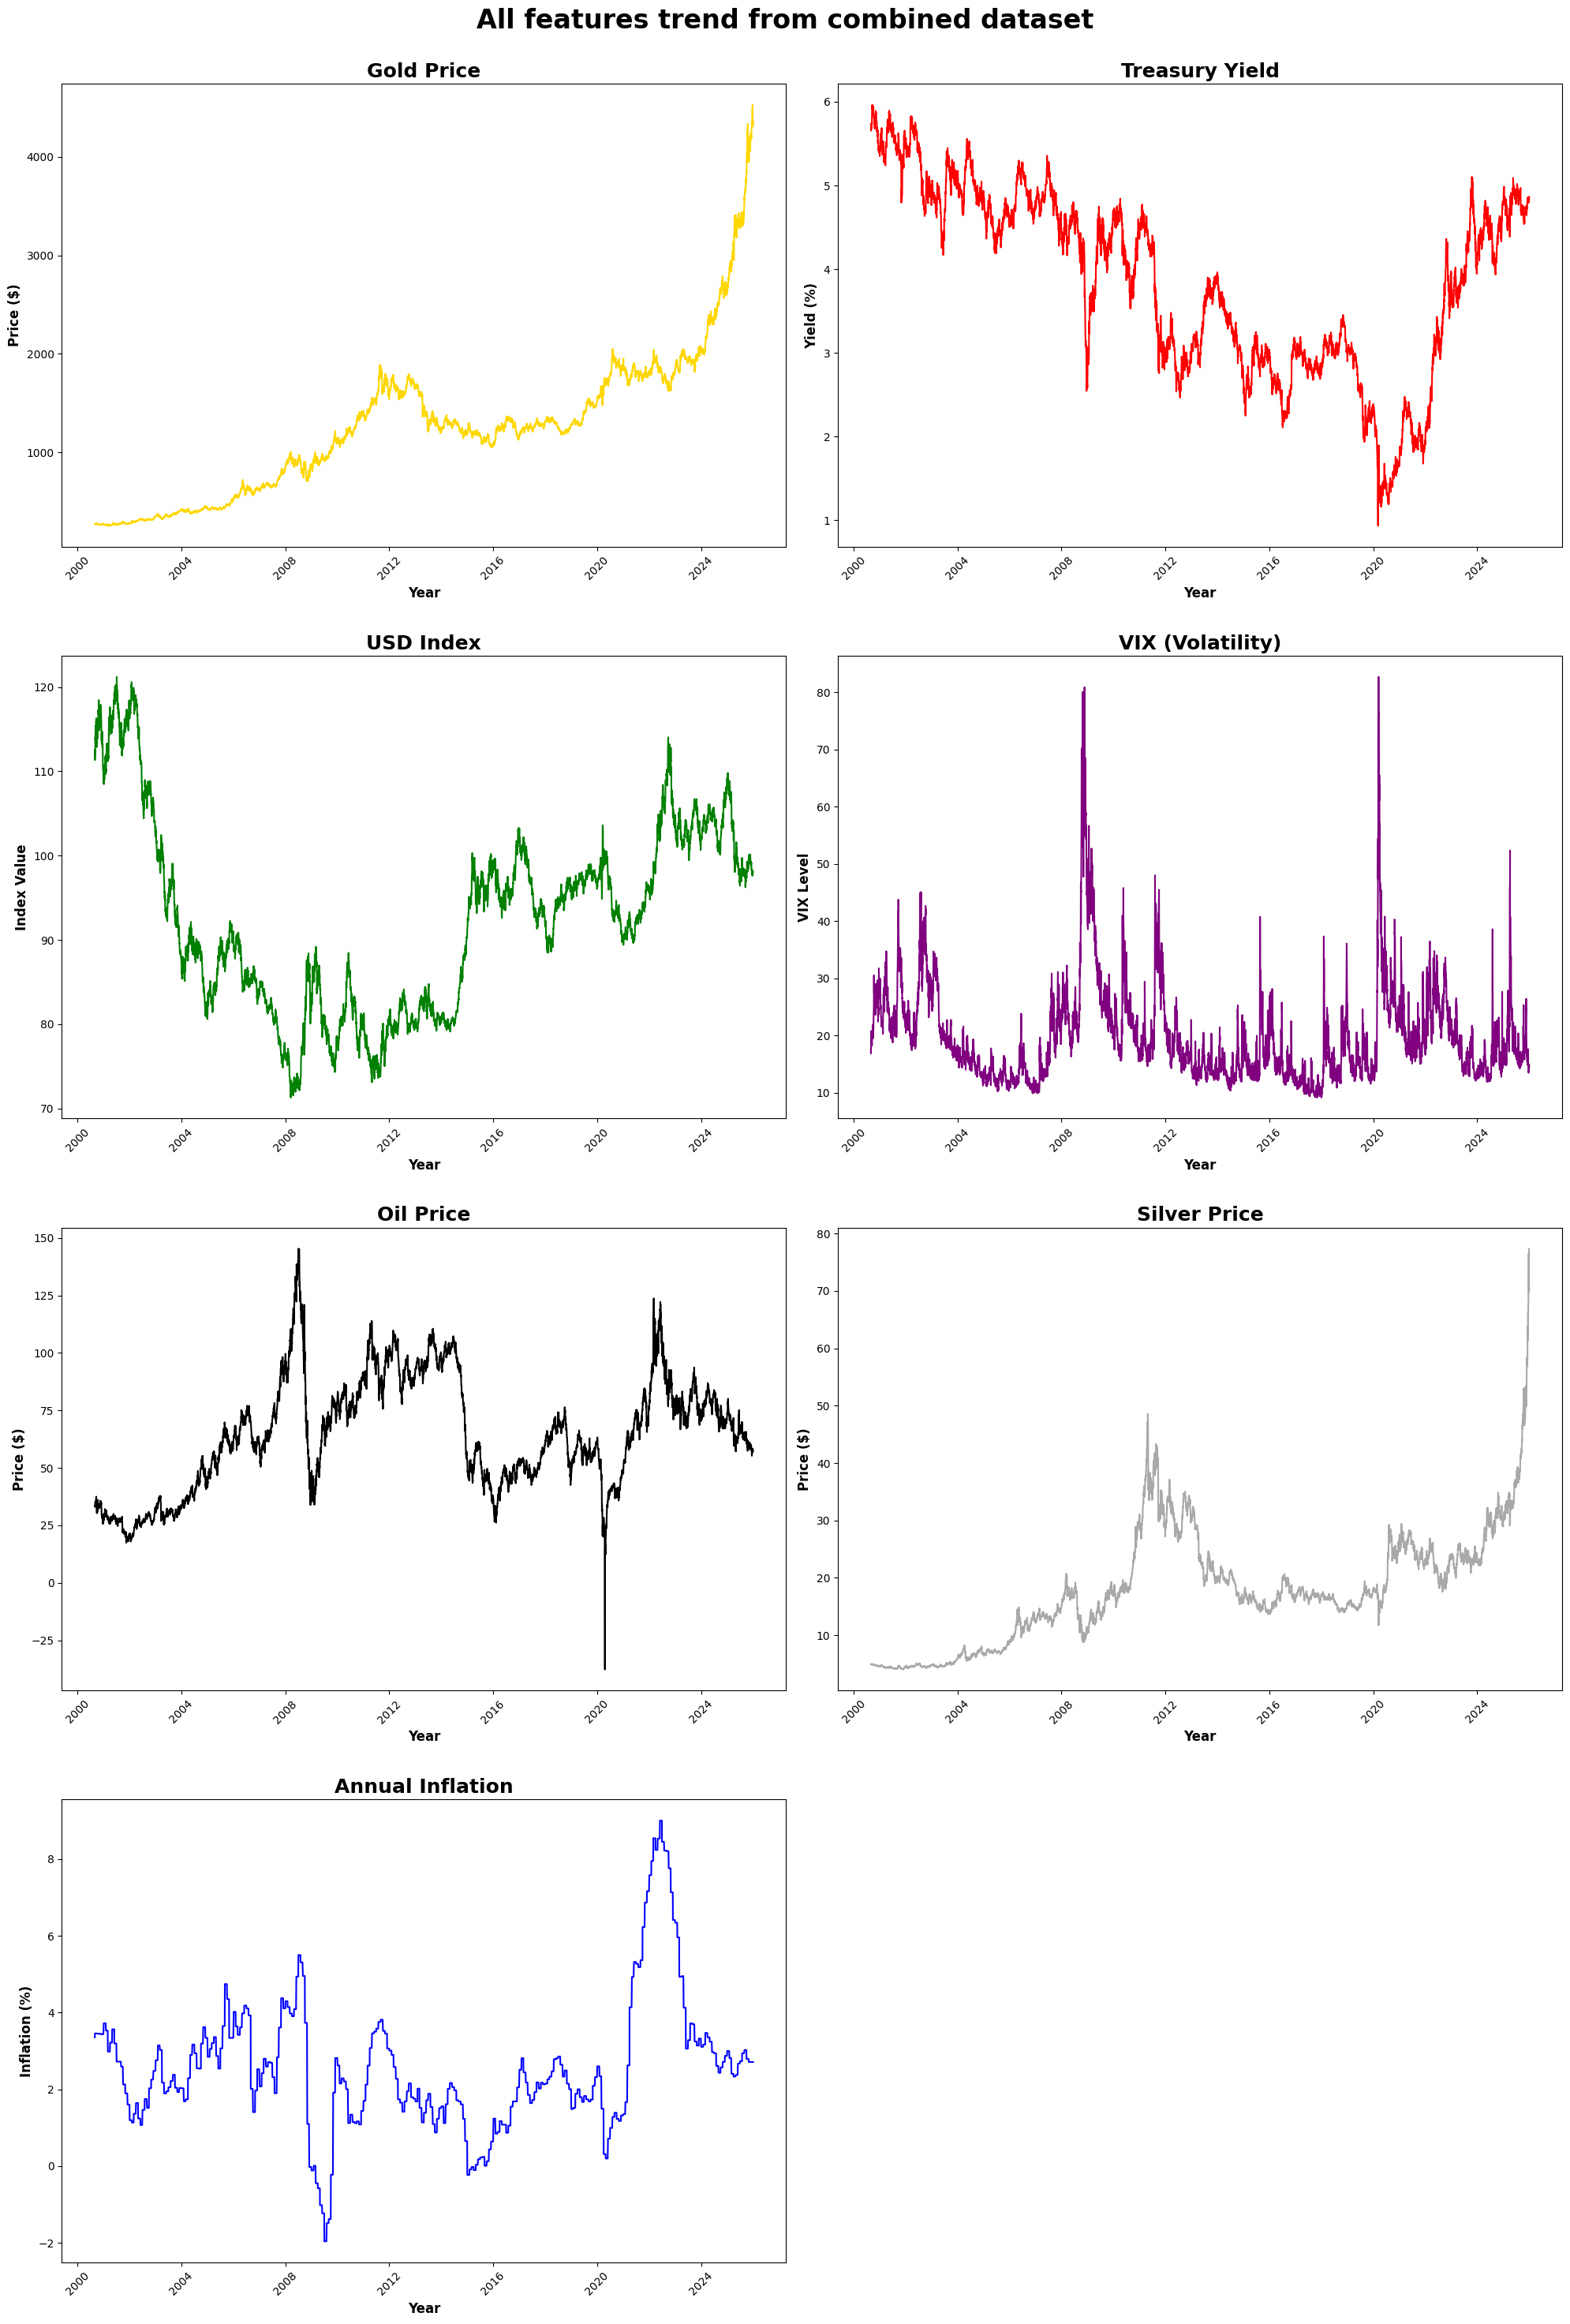

In [6]:
# Function to plot all the features collected in combined dataframe.

def plot_combined_data(combined_df):

    """
    This function helps to plot all the features fromk the dataframe.

    Parameters: combined_df: A combined dataset with all-features aligned to
                daily frequency.

    Returns: None
    """

    # To create a list of features available in the dataframe.
    available_columns = combined_df.columns.tolist()

    # To initialize subplots.
    fig, axes = plt.subplots(4, 2, figsize=(20,30)) # 4 rows, 2 columns, total 8 subplots.
    fig.suptitle('All features trend from combined dataset\n', fontsize=24, fontweight='bold')
    axes = axes.flatten() # To create 1D array to iterate through subplots easily.

    # To define plot configurations for each variable.
    plot_config = {'Gold_Price': {'color': 'gold', 'title': 'Gold Price', 'ylabel': 'Price ($)'},
                   'SILVER': {'color': 'darkgray', 'title': 'Silver Price', 'ylabel': 'Price ($)'},
                   'OIL': {'color': 'black', 'title': 'Oil Price', 'ylabel': 'Price ($)'},
                   'Treasury_yield': {'color': 'red', 'title': 'Treasury Yield', 'ylabel': 'Yield (%)'},
                   'USD_Index': {'color': 'green', 'title': 'USD Index', 'ylabel': 'Index Value'},
                   'VIX': {'color': 'purple', 'title': 'VIX (Volatility)', 'ylabel': 'VIX Level'},
                   'Inflation_Annual': {'color': 'blue', 'title': 'Annual Inflation', 'ylabel': 'Inflation (%)'}}

    # To plot subplots for each variables.
    for i, column in enumerate(available_columns):
        if i < len(axes):
            config = plot_config[column]
            axes[i].plot(combined_df.index, combined_df[column], color=config['color'], linewidth=1.5)
            axes[i].set_title('\n' + config['title'], fontweight='bold', fontsize=18)
            axes[i].set_ylabel(config['ylabel'], fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Year', fontsize=12, fontweight='bold')
            axes[i].grid(False)
            axes[i].tick_params(axis='x', rotation=45)

    # To hide unused subplot.
    for i in range(len(available_columns), len(axes)):
        axes[i].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_combined_data(combined_df)

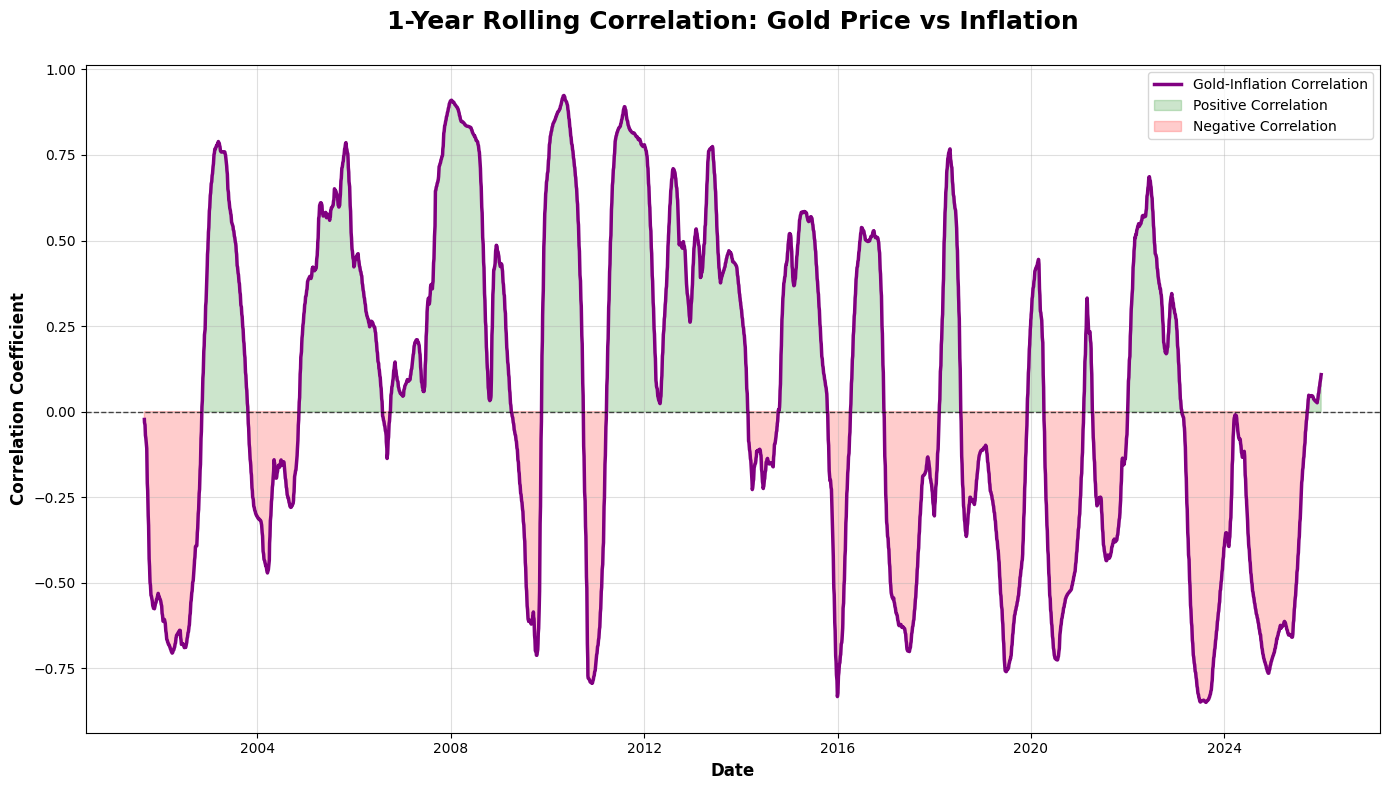

In [7]:
# Function to visualize the correlation between gold and inflation annual.

def plot_gold_inflation_correlation(df):

    """
    This function helps to plot 1-year rolling correlation between Gold Price
    and Inflation Annual.

    Parameters: df = dataframe.

    Returns: None
    """

    # To calculate 1-year rolling correlation between gold and inflation.
    # window=252 as there are roughly 252 trading days in a year.
    rolling_corr = df['Gold_Price'].rolling(window=252).corr(df['Inflation_Annual'])

    # To create the correlation plot.
    plt.figure(figsize=(14, 8))
    plt.plot(rolling_corr.index, rolling_corr, color='purple', linewidth=2.5, label='Gold-Inflation Correlation')

    # To add shaded regions for positive/negative correlation.
    plt.fill_between(rolling_corr.index, rolling_corr, 0, where=rolling_corr >= 0,
                     color='green', alpha=0.2, label='Positive Correlation')
    plt.fill_between(rolling_corr.index, rolling_corr, 0, where=rolling_corr <= 0,
                     color='red', alpha=0.2, label='Negative Correlation')

    plt.axhline(y=0, color='black', linestyle='--', alpha=0.7, linewidth=1)
    plt.title('1-Year Rolling Correlation: Gold Price vs Inflation\n', fontsize=18, fontweight='bold')
    plt.ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
    plt.xlabel('Date', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_gold_inflation_correlation(combined_df)

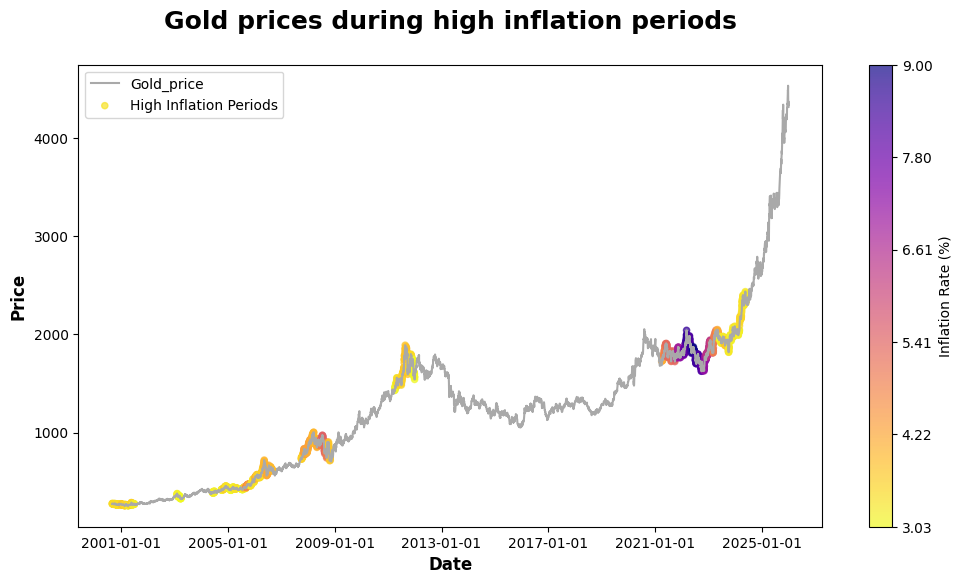

In [8]:
# Function to visualize gold behaviour during high inflation.

def plot_gold_vs_inflation(df):

    """
    This function helps to plot gold prices during high inflation periods.

    Parameters: df = Combined dataset with financial variables

    Returns: None
    """

    high_inflation_threshold = df['Inflation_Annual'].quantile(0.70)
    high_inflation_periods = df[df['Inflation_Annual'] >= high_inflation_threshold]

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Gold_Price'], color='darkgray', label='Gold_price')
    scatter = plt.scatter(high_inflation_periods.index, high_inflation_periods['Gold_Price'],
                          c=high_inflation_periods['Inflation_Annual'], cmap='plasma_r',
                          s=20, alpha=0.7, label='High Inflation Periods')

    # To set the colorbar to threshold.
    vmin = high_inflation_threshold
    vmax = high_inflation_periods['Inflation_Annual'].max()
    scatter.set_clim(vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(scatter)
    cbar.set_label('Inflation Rate (%)')
    ticks = [vmin] + list(np.linspace(vmin, vmax, 6)[1:])
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

    plt.title('Gold prices during high inflation periods\n', fontsize=18, fontweight='bold')
    plt.ylabel('Price', fontsize=12, fontweight='bold')
    plt.xlabel('Date', fontsize=12, fontweight='bold')
    plt.legend()
    plt.xticks(pd.date_range(start=df.index.min(), end=df.index.max(), freq='4YS'))
    plt.show()

plot_gold_vs_inflation(combined_df)

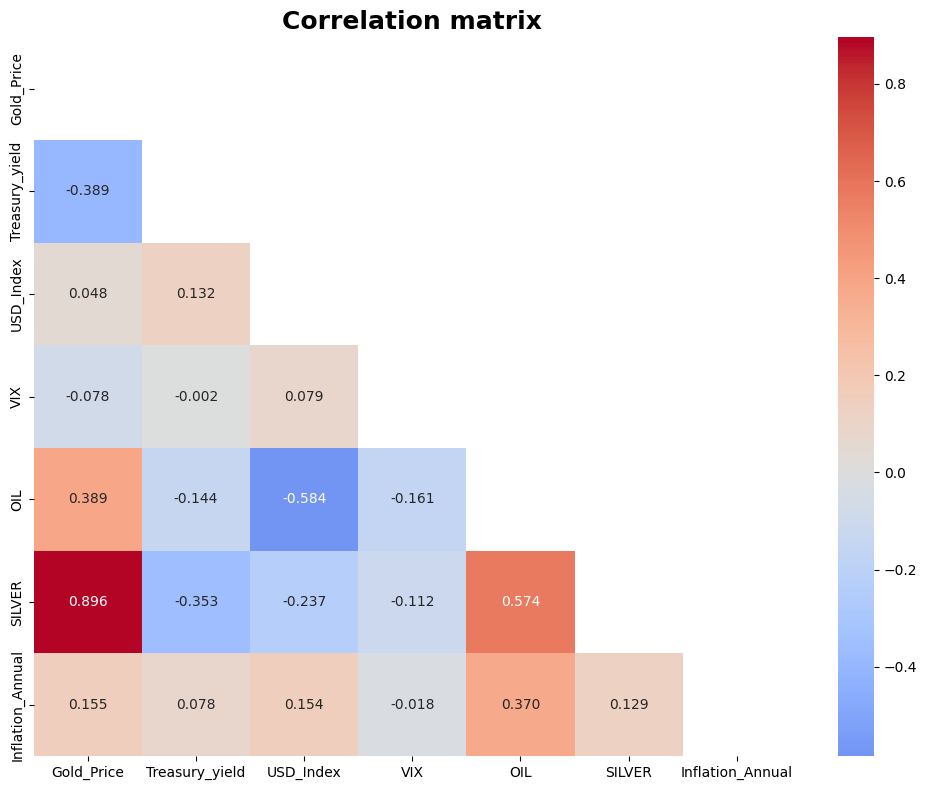

In [9]:
# Function to plot correlation heatmap.

def plot_correlation_heatmap(df, figsize):

    """
    This function helps to plot correlation heatmap for the dataset.

    Parameters: df = dataframe.
                figsize = tuple, Figure size for the heatmap.

    Returns: None
    """

    # To calculate correlation matrix of the dataframe.
    corr_matrix = df.corr()

    # To create heatmap using correlation matrix.
    plt.figure(figsize=figsize)

    # To mask the upper triangle for cleaner output.
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                fmt='.3f')

    plt.title('Correlation matrix', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

corr_matrix = plot_correlation_heatmap(combined_df,(10,8))

In [11]:
# To check the correlation of all the features with gold in percentage change.
print("\ncorrelation of features with gold (daily percentage change)")
print("=" * 60)
daily_c = combined_df.pct_change().dropna()
correlations = daily_c.corr()['Gold_Price'].sort_values(ascending=False)
print(correlations)


correlation of features with gold (daily percentage change)
Gold_Price          1.000000
SILVER              0.775165
OIL                 0.098019
VIX                 0.009471
Inflation_Annual    0.003046
Treasury_yield     -0.138251
USD_Index          -0.410419
Name: Gold_Price, dtype: float64


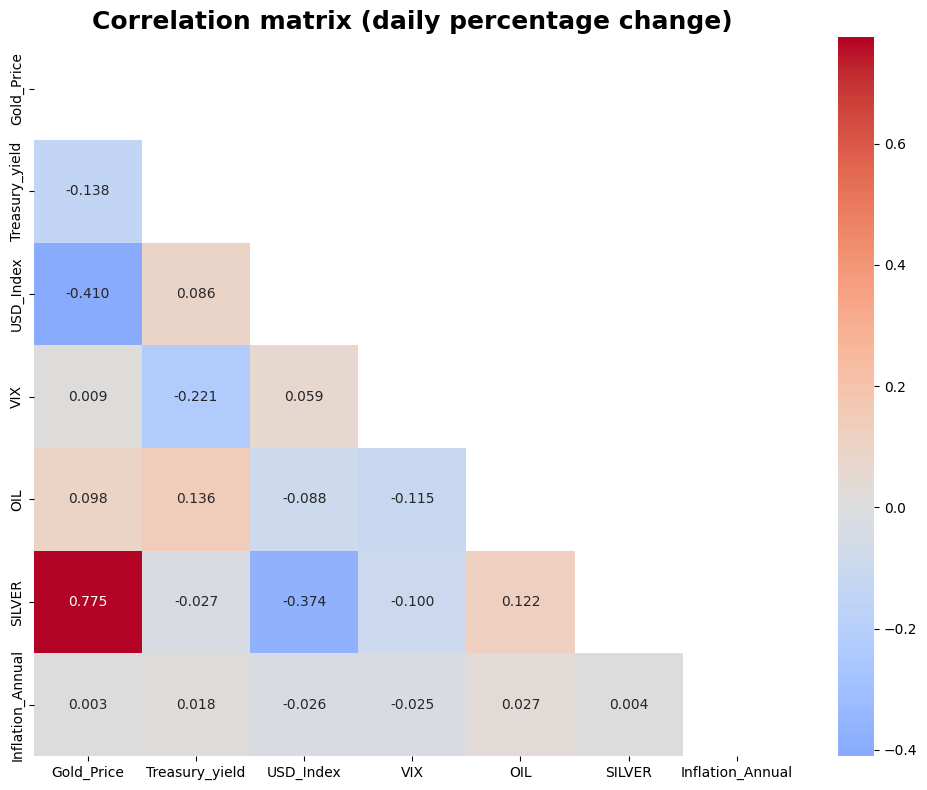

In [12]:
# Function to plot correlation heatmap.

def plot_correlation_heatmap(df, figsize):

    """
    This function helps to plot correlation heatmap for the dataset.

    Parameters: df = dataframe.
                figsize = tuple, Figure size for the heatmap.

    """

    # To calculate correlation matrix of the dataframe.
    corr_matrix = df.corr()

    # To create heatmap using correlation matrix.
    plt.figure(figsize=figsize)

    # To mask the upper triangle for cleaner output.
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                fmt='.3f')

    plt.title('Correlation matrix (daily percentage change)', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

corr_matrix = plot_correlation_heatmap(daily_c,(10,8))

# Step-3 : *Machine Learning.*




* Aim for this machine learning project is to predict gold direction
on weekly basis.
* Model is trained on major (+ and -) correlated features of cobined_df dataframe and some technical indicators which I have created in below functions.







In [13]:
# To install required packages and import libraries.

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix,
                             balanced_accuracy_score)
import warnings
warnings.filterwarnings('ignore')

In [14]:
# To create features to train the model.

def create_features(df):

    """
    This function helps to create weekly prediction features from daily data.

    Parameters: df = Combined dataset with financial variables.

    Returns: data = DataFrame with weekly prediction features.
    """

    # To make a copy of the orignal dataframe to avoid modifying it.
    data = df.copy()

    # To creat economic feature of real yield.
    # Real yield calculation based on Federal Reserve research: Gürkaynak, Sack, & Wright (2008)
    data['Real_Yield'] = data['Treasury_yield'] - data['Inflation_Annual']
    data['Real_Yield_Change_5d'] = data['Real_Yield'] - data['Real_Yield'].shift(5)
    data['Real_Yield_Change_10d'] = data['Real_Yield'] - data['Real_Yield'].shift(10)

    # # To create features based on VIX.
    # #
    # To create vix level feature based on VIX prices. (fear level)
    # Low: < 15, Medium: 15-30, High: > 30
    vix_level = pd.cut(data['VIX'], bins=[0, 15, 30, 100], labels=[0, 1, 2])
                                                    # 0=Low, 1=Medium, 2=High
    data['VIX_Level'] = vix_level.astype(float)

    # To create features of percentage changes in price of vix in last 10
    # days.
    data['VIX_Change_10d'] = data['VIX'].pct_change(10)

    # To create feature of vix's current price vs. it's 10 days avrage price.
    data['VIX_vs_10d_Avg'] = data['VIX'] / data['VIX'].rolling(10).mean() - 1

    # # To create features based on ratio of last 5 days between gold and silver,
    # # gold and oil.
    Gold_silver = data['Gold_Price'] / data['SILVER']
    Gold_oil = data['Gold_Price'] / data['OIL']
    Gold_dxy = data['Gold_Price'] / data['USD_Index']
    Gold_yield = data['Gold_Price'] / data['Treasury_yield']
    Gold_ryield = data['Gold_Price'] / data['Real_Yield']

    data['Gold_Silver_Ratio_5d_Avg'] = Gold_silver.rolling(5).mean()
    data['Gold_Yield_Ratio_5d_Avg'] = Gold_yield.rolling(5).mean()
    data['Gold_Real_Yield_Ratio_5d_Avg'] = Gold_ryield.rolling(5).mean()

    # To also get that ratio in percentage.
    data['Gold_DXY_Ratio_Change_5d'] = Gold_dxy.pct_change(5)

    # # To create features based on CPI data (inflation).
    # #
    # Inflation data is publised on monthly basis so we need to detect when it
    # changes in the data.
    # To create a flag for new inflation data.
    data['Inflation_Change_Flag'] = (data['Inflation_Annual'] != data['Inflation_Annual'].shift(1)).astype(int)

    # To create a feature for the monthly inflation change (current vs previous month).
    inflation_changes = data[data['Inflation_Change_Flag'] == 1]['Inflation_Annual'].diff()

    # To forward fill the change values to all days until next update.
    data['Inflation_Actual_Change'] = inflation_changes.reindex(data.index).ffill()

    # # To create features for the 10-day rolling correlation between gold and
    # # DXY, yield, and silver.
    # Gold vs DXY relationship.
    data['Gold_DXY_Corr_10d'] = data['Gold_Price'].pct_change().rolling(10).corr(data['USD_Index'].pct_change())

    # Gold vs Yield relationship.
    data['Gold_Yield_Corr_10d'] = data['Gold_Price'].pct_change().rolling(10).corr(data['Treasury_yield'].pct_change())

    # Gold vs Silver correlation.
    data['Gold_Silver_Corr_10d'] = data['Gold_Price'].pct_change().rolling(10).corr(data['SILVER'].pct_change())

    # To remove unnecessary features.
    data = data.drop(['Inflation_Change_Flag'], axis=1, errors='ignore')

    # To remove NaN values from the data. (created during rolling calculations)
    initial_len = len(data)
    data = data.dropna()
    final_len = len(data)

    print(f"Removed {initial_len - final_len} rows with NaN")
    print(f"Final dataset shape: {data.shape}")
    print(f"Date range after cleaning: {data.index.min()} to {data.index.max()}")
    print(f"Number of features: {len(data.columns)}")

    return data

In [15]:
features_df = create_features(combined_df)

Removed 10 rows with NaN
Final dataset shape: (6335, 21)
Date range after cleaning: 2000-09-14 00:00:00 to 2026-01-02 00:00:00
Number of features: 21


In [16]:
def filter_to_fridays(df):

    """
    This function helps to filter data to Fridays only.

    Parameters: df = Combined dataset with financial variables

    Returns: friday_data = DataFrame with only Fridays

    """

    # To get only Fridays from the data and sort it by date.
    friday_data = df[df.index.dayofweek == 4].copy()
    friday_data = friday_data.sort_index()

    # To get the gold's next week return.
    gold_returns = friday_data['Gold_Price'].pct_change().shift(-1)

    # To create the binary target: 1 if next week's return > 0, else 0. (direction)
    friday_data['Target_Next_Week_Up'] = (gold_returns > 0).astype(int)

    # Here we are working with the current data so we don't have next week's
    # price. So the above direction feature will create a Nan value in the end.
    # To remove the last row.
    friday_data = friday_data.iloc[:-1]

    print(f"Friday Data: {len(friday_data)} weeks")
    print(f"Target: {friday_data['Target_Next_Week_Up'].mean():.1%} Up rate")

    return friday_data

In [17]:
friday_features = filter_to_fridays(features_df)

Friday Data: 1264 weeks
Target: 56.6% Up rate


In [18]:
def prepare_training_data(df):

    """
    This function helps to prepare the data for training.

    Parameters: friday_df = DataFrame with only Fridays.

    Returns: X, y, feature_cols
    """

    # To exclude the raw prices and next week's direction to avoid data leakage.
    exclude_cols = ['Gold_Price', 'SILVER', 'OIL', 'USD_Index', 'VIX',
                    'Treasury_yield', 'Inflation_Annual', 'Target_Next_Week_Up']
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    X = df[feature_cols]
    y = df['Target_Next_Week_Up']

    print(f"Prepared training data:\n")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Number of features: {len(feature_cols)}")
    print(f"Target distribution: {y.value_counts().to_dict()}")

    return X, y, feature_cols

In [19]:
X, y, feature_cols = prepare_training_data(friday_features)

Prepared training data:

X shape: (1264, 14)
y shape: (1264,)
Number of features: 14
Target distribution: {1: 716, 0: 548}


In [20]:
def time_based_split(X, y, test_size):

    """
    This function helps to split data into train and test.

    Parameters: X = DataFrame with features.
                y = target.
                test_size = float, Proportion of data to be used for testing.

    Returns: X_train = DataFrame with training features.
             X_test = DataFrame with testing features.
             y_train = Training targets.
             y_test = Testing targets.
    """

    split_point = int(len(X) * (1 - test_size))

    X_train = X.iloc[:split_point]
    X_test = X.iloc[split_point:]
    y_train = y.iloc[:split_point]
    y_test = y.iloc[split_point:]

    print(f"\nTime-based split:")
    print(f"Training period: {X_train.index.min().date()} to {X_train.index.max().date()}")
    print(f"Testing period: {X_test.index.min().date()} to {X_test.index.max().date()}")
    print(f"Train samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    return X_train, X_test, y_train, y_test

In [21]:
X_train, X_test, y_train, y_test = time_based_split(X, y, test_size=0.2)


Time-based split:
Training period: 2000-09-15 to 2020-12-18
Testing period: 2021-01-08 to 2025-12-26
Train samples: 1011
Test samples: 253


In [22]:
def scale_features(X_train, X_test):

    """
    This function helps to normalize features using standardScaler.

    Parameters: X_train = DataFrame with training features.
                X_test : DataFrame with test features.

    Returns: X_train_scaled = DataFrame with scaled training data.
             X_test_scaled = DataFrame with scaled test data.
             scaler = Standardscaler with trained scaler object.
    """

    # To initialize the scaler.
    scaler = StandardScaler()

    # To fit the scaler on training data only and transform it to both traning
    # and testing data. on training data and transform both.
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # To convert scaled arrays back to DataFrames with original column names and
    # dates. StandardScaler.fit_transform() returns numpy arrays, losing feature
    # names and timestamps. We need DataFrames for proper model training and
    # evaluation
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns,
                                  index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns,
                                  index=X_test.index)

    print(f"Features scaled using StandardScaler")

    return X_train_scaled, X_test_scaled, scaler

In [23]:
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

Features scaled using StandardScaler


**Training and testing models**

In [24]:
def perform_time_series_cv(model, X_train, y_train, model_name, n_splits):

    """
    This function performs time series cross-validation for any model and returns
    the cross-validation scores.

    Parameters: model : Any machine learning model.
                X_train : DataFrame with training features.
                y_train : Series with training target values.
                model_name : Name of the model for display purposes.
                n_splits : Number of folds for cross-validation.

    Returns: cv_scores : Dictionary with cross-validation metrics.

    """
    print(f"\nPerforming {n_splits}-fold Time Series Cross-Validation for {model_name}:")

    # To configure time series cross-validation.
    tscv = TimeSeriesSplit(n_splits=n_splits)

    # To store cross-validation metrics for each fold.
    cv_train_accs = []
    cv_val_accs = []
    cv_f1_scores = []
    cv_bal_accs = []
    cv_precisions = []
    cv_recalls = []

    # To iterate through each fold of cross-validation.
    for fold, (train_i, val_i) in enumerate(tscv.split(X_train), 1):

        # To split data into training and validation for current fold.
        X_tr = X_train.iloc[train_i]
        X_val = X_train.iloc[val_i]
        y_tr = y_train.iloc[train_i]
        y_val = y_train.iloc[val_i]

        # To train model on training fold.
        model.fit(X_tr, y_tr)

        # To make predictions on training and validation data.
        y_tr_pred = model.predict(X_tr)
        y_val_pred = model.predict(X_val)

        # To calculate performance metrics for current fold.
        train_acc = accuracy_score(y_tr, y_tr_pred)
        val_acc = accuracy_score(y_val, y_val_pred)
        f1 = f1_score(y_val, y_val_pred, zero_division=0)
        bal_acc = balanced_accuracy_score(y_val, y_val_pred)
        precision = precision_score(y_val, y_val_pred, zero_division=0)
        recall = recall_score(y_val, y_val_pred, zero_division=0)

        # To store metrics for current fold.
        cv_train_accs.append(train_acc)
        cv_val_accs.append(val_acc)
        cv_f1_scores.append(f1)
        cv_bal_accs.append(bal_acc)
        cv_precisions.append(precision)
        cv_recalls.append(recall)

        print(f"Fold {fold}/{n_splits}: Train={train_acc:.4f}, Val={val_acc:.4f}, "
              f"BalAcc={bal_acc:.4f}, F1={f1:.4f}")

    # To calculate mean performance across all folds.
    mean_train = np.mean(cv_train_accs)
    mean_val = np.mean(cv_val_accs)
    mean_f1 = np.mean(cv_f1_scores)
    mean_bal = np.mean(cv_bal_accs)
    mean_precision = np.mean(cv_precisions)
    mean_recall = np.mean(cv_recalls)
    std_val = np.std(cv_val_accs)
    gap = mean_train - mean_val

    # To print cross-validation summary results.
    print("\nCross-Validation Summary:")
    print(f"Mean Train Accuracy:    {mean_train:.4f}")
    print(f"Mean Val Accuracy:      {mean_val:.4f} (±{std_val:.4f})")
    print(f"Mean Balanced Accuracy: {mean_bal:.4f}")
    print(f"Mean F1 Score:          {mean_f1:.4f}")
    print(f"Mean Precision:         {mean_precision:.4f}")
    print(f"Mean Recall:            {mean_recall:.4f}")
    print(f"Train-Val Gap:          {gap:.4f}", end=" ")

    # To provide interpretation of overfitting gap.
    if gap < 0.05:
        print("Excellent generalization!")
    elif gap < 0.15:
        print("Good generalization")
    else:
        print("Overfitting detected")

    # To store cross-validation scores in dictionary.
    cv_scores = {'train_acc': mean_train,
                 'val_acc': mean_val,
                 'balanced_acc': mean_bal,
                 'f1': mean_f1,
                 'precision': mean_precision,
                 'recall': mean_recall,
                 'std': std_val,
                 'gap': gap}

    return cv_scores

In [25]:
def evaluate_model_generic(model, X_train, X_test, y_train, y_test, model_name):

    """
    This function provides generic evaluation for any model.

    Parameters: model : Any sklearn model with fit/predict methods.
                X_train : DataFrame with training features.
                X_test : DataFrame with test features.
                y_train : Series with training target values.
                y_test : Series with test target values.
                model_name : Name of the model for display purposes.

    Returns: results : Dictionary containing all evaluation metrics.
    """

    print(f"\nModel evalution for {model_name.upper()}")

    # To get model predictions for training and test data.
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # To calculate various performance metrics.
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    # To print the calculated performance metrics.
    print("\nPerformance Metrics:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:     {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")
    print(f"F1 Score:          {f1:.4f}")

    # To check for overfitting by comparing training and test accuracy.
    gap = train_acc - test_acc
    print("\nGeneralization Analysis:")
    print(f"Train-Test Gap:    {gap:+.4f}", end=" ")

    # To provide interpretation of the overfitting gap.
    if gap < 0.05:
        print("Excellent generalization!")
    elif gap < 0.15:
        print("Good generalization")
    else:
        print("Overfitting detected")

    # To create and display the confusion matrix.
    cm = confusion_matrix(y_test, y_test_pred)
    print("\n Confusion Matrix:")
    print("             Predicted Down Predicted Up")
    print(f"Actual Down     {cm[0,0]:4d}          {cm[0,1]:4d}")
    print(f"Actual Up       {cm[1,0]:4d}          {cm[1,1]:4d}")

    # To calculate per-class accuracy for detailed analysis.
    print("\nPer-Class Performance:")
    down_total = cm[0,0] + cm[0,1]
    up_total = cm[1,0] + cm[1,1]

    # To calculate accuracy for down weeks.
    if down_total > 0:
        down_acc = cm[0,0] / down_total
        print(f"Down weeks:  {cm[0,0]:3d}/{down_total:3d} correct ({down_acc:.1%})")

    # To calculate accuracy for up weeks.
    if up_total > 0:
        up_acc = cm[1,1] / up_total
        print(f"Up weeks:    {cm[1,1]:3d}/{up_total:3d} correct ({up_acc:.1%})")

    # Try to get feature importance if available
    feature_importance = None
    if hasattr(model, 'feature_importances_'):
        feature_importance = pd.DataFrame({'Feature': X_train.columns,
                                           'Importance': model.feature_importances_}).sort_values('Importance', ascending=False)
    elif hasattr(model, 'coef_'):
        # For linear models
        feature_importance = pd.DataFrame({'Feature': X_train.columns,
                                           'Coefficient': model.coef_[0] if len(model.coef_.shape) > 1 else model.coef_,
                                           'Abs_Coefficient': abs(model.coef_[0] if len(model.coef_.shape) > 1 else model.coef_)}).sort_values('Abs_Coefficient', ascending=False)

    # To store all results in a dictionary for further use.
    results = {'train_acc': train_acc,
               'test_acc': test_acc,
               'balanced_acc': test_bal_acc,
               'precision': precision,
               'recall': recall,
               'f1': f1,
               'gap': gap,
               'confusion_matrix': cm,
               'feature_importance': feature_importance}

    if feature_importance is not None:
        print(f"\n  Top 5 Most Important Features:")
        for i in range(min(5, len(feature_importance))):
            feat = feature_importance.iloc[i]
            if 'Coefficient' in feat:
                direction = "UP" if feat['Coefficient'] > 0 else "DOWN"
                print(f"{i+1:2d}. {feat['Feature']:30s}: {feat['Coefficient']:+.4f} (predicts {direction})")
            else:
                print(f"{i+1:2d}. {feat['Feature']:30s}: {feat['Importance']:.4f}")

    return results

In [26]:
def train_model_generic(model, X_train, y_train, X_test, y_test, model_name="Model"):

    """
    This is a complete generic training pipeline for any model.

    Parameters: model : Any sklearn model.
                X_train, y_train : Training data.
                X_test, y_test : Test data.
                model_name : Name for display.

    Returns: trained_model : Trained model.
             cv_scores : Cross-validation scores.
             results : Test evaluation results.
    """

    print(f"TRAINING {model_name.upper()}")
    print(f"{'='*80}")

    # To perform cross-validation on the model.
    cv_scores = perform_time_series_cv(model, X_train, y_train, model_name, 5)

    # To train the model on full training set.
    print(f"\nTraining Final Model on Full Training Set...")
    model.fit(X_train, y_train)
    print(f"    {model_name} training complete!")

    # To evaluate the model on test set.
    results = evaluate_model_generic(model, X_train, X_test, y_train, y_test, model_name)

    # To print the model performance summary.
    print(f"\n{model_name.upper()} SUMMARY")
    print(f"{'='*30}")
    print(f"Test Accuracy:     {results['test_acc']:.4f}")
    print(f"Balanced Accuracy: {results['balanced_acc']:.4f}")
    print(f"F1 Score:          {results['f1']:.4f}")
    print(f"Precision:         {results['precision']:.4f}")
    print(f"Recall:            {results['recall']:.4f}")
    print(f"Overfitting Gap:   {results['gap']:.4f}")

    return model, cv_scores, results

- Logistic regression

In [27]:
def train_logistic_regression(X_train, y_train, X_test, y_test):

    """
    This function trains a Logistic Regression model.

    Parameters: X_train, y_train : Training data.
                X_test, y_test : Test data.

    Returns: model : Trained Logistic Regression model.
             cv_scores : Cross-validation scores.
             results : Test evaluation results.
    """

    # To initialize the model with specified parameters.
    model = LogisticRegression(C=0.01,
                               penalty='l2',
                               max_iter=1000,
                               random_state=42,
                               solver='lbfgs')

    # To use the generic training pipeline.
    model, cv_scores, results = train_model_generic(model, X_train, y_train,
                                                    X_test, y_test, "Logistic Regression")

    return model, cv_scores, results

In [28]:
model_lr, cv_lr, results_lr = train_logistic_regression(X_train_scaled, y_train,
                                                        X_test_scaled, y_test)

TRAINING LOGISTIC REGRESSION

Performing 5-fold Time Series Cross-Validation for Logistic Regression:
Fold 1/5: Train=0.5731, Val=0.6131, BalAcc=0.4937, F1=0.7584
Fold 2/5: Train=0.5782, Val=0.5536, BalAcc=0.4639, F1=0.7059
Fold 3/5: Train=0.5858, Val=0.5536, BalAcc=0.5013, F1=0.7104
Fold 4/5: Train=0.5704, Val=0.4940, BalAcc=0.5047, F1=0.6473
Fold 5/5: Train=0.5599, Val=0.3988, BalAcc=0.3976, F1=0.4294

Cross-Validation Summary:
Mean Train Accuracy:    0.5735
Mean Val Accuracy:      0.5226 (±0.0725)
Mean Balanced Accuracy: 0.4722
Mean F1 Score:          0.6503
Mean Precision:         0.5415
Mean Recall:            0.8406
Train-Val Gap:          0.0508 Good generalization

Training Final Model on Full Training Set...
    Logistic Regression training complete!

Model evalution for LOGISTIC REGRESSION

Performance Metrics:
Training Accuracy: 0.5618
Test Accuracy:     0.6008
Balanced Accuracy: 0.5173
Precision:         0.6017
Recall:            0.9667
F1 Score:          0.7417

Generaliza

In [29]:
def tune_logistic_regression(X_train, y_train, X_test, y_test):

    """
    This function performs hyperparameter tuning for Logistic Regression.

    Parameters: X_train, y_train : Training data.
                X_test, y_test : Test data.
    Returns: best_model : Best Logistic Regression model.
             cv_scores : Cross-validation scores.
             results : Test evaluation results.
    """

    # To define the parameter grid for ALL parameters.
    param_grid = {'C': [0.011, 0.057, 0.113],
                  'penalty': ['l1', 'l2'],
                  'max_iter': [500, 1000],
                  'fit_intercept': [True],
                  'class_weight': [None, 'balanced', {0: 1, 1: 1.1}, {0: 1.1, 1: 1}],
                  'random_state': [42, 123],
                  'solver': ['lbfgs', 'newton-cg']}

    # To configure time series cross-validation.
    tscv = TimeSeriesSplit(n_splits=5)

    # To create GridSearchCV for hyperparameter tuning.
    grid_search = GridSearchCV(estimator=LogisticRegression(random_state=42),
                               param_grid=param_grid,
                               cv=tscv,
                               scoring='balanced_accuracy',
                               n_jobs=-1,
                               verbose=1,
                               refit=True)

    # To execute grid search.
    print(f"Tuning Logistic Regression...")
    grid_search.fit(X_train, y_train)

    # To get best model and all parameters.
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print(f"Best Parameters Found:")
    print(f"C: {best_params.get('C')}")
    print(f"penalty: {best_params.get('penalty')}")
    print(f"max_iter: {best_params.get('max_iter')}")
    print(f"fit_intercept: {best_params.get('fit_intercept')}")
    print(f"class_weight: {best_params.get('class_weight')}")
    print(f"random_state: {best_params.get('random_state')}")
    print(f"solver: {best_params.get('solver')}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")

    # To use the generic training pipeline with tuned model.
    model, cv_scores, results = train_model_generic(best_model, X_train, y_train,
                                                    X_test, y_test, "Tuned Logistic Regression")

    return model, cv_scores, results

In [30]:
results_dict = {}

lr_model, lr_cv, lr_results = tune_logistic_regression(X_train, y_train, X_test, y_test)
results_dict['Logistic Regression'] = {'model': lr_model,
                                       'cv_scores': lr_cv,
                                       'results': lr_results}

Tuning Logistic Regression...
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best Parameters Found:
C: 0.011
penalty: l2
max_iter: 500
fit_intercept: True
class_weight: {0: 1.1, 1: 1}
random_state: 42
solver: lbfgs
Best CV Score: 0.5088
TRAINING TUNED LOGISTIC REGRESSION

Performing 5-fold Time Series Cross-Validation for Tuned Logistic Regression:
Fold 1/5: Train=0.5322, Val=0.4048, BalAcc=0.5238, F1=0.0909
Fold 2/5: Train=0.5929, Val=0.5952, BalAcc=0.5303, F1=0.7143
Fold 3/5: Train=0.5917, Val=0.5357, BalAcc=0.4852, F1=0.6953
Fold 4/5: Train=0.5807, Val=0.5000, BalAcc=0.5048, F1=0.5800
Fold 5/5: Train=0.5575, Val=0.4464, BalAcc=0.5000, F1=0.0000

Cross-Validation Summary:
Mean Train Accuracy:    0.5710
Mean Val Accuracy:      0.4964 (±0.0667)
Mean Balanced Accuracy: 0.5088
Mean F1 Score:          0.4161
Mean Precision:         0.5325
Mean Recall:            0.5091
Train-Val Gap:          0.0746 Good generalization

Training Final Model on Full Training Set...
    Tune

- Ridge classifier

In [31]:
def train_ridge_classifier(X_train, y_train, X_test, y_test):

    """
    This function trains a Ridge Classifier model.

    Parameters: X_train, y_train : Training data.
                X_test, y_test : Test data.

    Returns: model : Trained Ridge Classifier model.
             cv_scores : Cross-validation scores.
             results : Test evaluation results.
    """

    # To initialize the Ridge Classifier model.
    model = RidgeClassifier(alpha=10,
                            solver='svd',
                            random_state=42,
                            class_weight='balanced')

    # To use the generic training pipeline.
    model, cv_scores, results = train_model_generic(model, X_train, y_train,
                                                    X_test, y_test, "Ridge Classifier")

    return model, cv_scores, results

In [32]:
model_ridge, cv_ridge, results_ridge = train_ridge_classifier(X_train_scaled, y_train,
                                                              X_test_scaled, y_test)

TRAINING RIDGE CLASSIFIER

Performing 5-fold Time Series Cross-Validation for Ridge Classifier:
Fold 1/5: Train=0.6433, Val=0.5774, BalAcc=0.4968, F1=0.7078
Fold 2/5: Train=0.5605, Val=0.5060, BalAcc=0.5530, F1=0.4503
Fold 3/5: Train=0.5641, Val=0.4702, BalAcc=0.4376, F1=0.6079
Fold 4/5: Train=0.5511, Val=0.5119, BalAcc=0.5085, F1=0.4225
Fold 5/5: Train=0.5552, Val=0.4286, BalAcc=0.4787, F1=0.0204

Cross-Validation Summary:
Mean Train Accuracy:    0.5748
Mean Val Accuracy:      0.4988 (±0.0493)
Mean Balanced Accuracy: 0.4949
Mean F1 Score:          0.4418
Mean Precision:         0.5064
Mean Recall:            0.4542
Train-Val Gap:          0.0760 Good generalization

Training Final Model on Full Training Set...
    Ridge Classifier training complete!

Model evalution for RIDGE CLASSIFIER

Performance Metrics:
Training Accuracy: 0.5153
Test Accuracy:     0.5217
Balanced Accuracy: 0.5404
Precision:         0.6408
Recall:            0.4400
F1 Score:          0.5217

Generalization Analysi

In [33]:
def tune_ridge_classifier(X_train, y_train, X_test, y_test):

    """
    This function performs hyperparameter tuning for Ridge Classifier.

    Parameters: X_train, y_train : Training data.
                X_test, y_test : Test data.
    Returns: best_model : Best Ridge Classifier model.
             cv_scores : Cross-validation scores.
             results : Test evaluation results.
    """

    # To define the parameter grid for ALL parameters.
    param_grid = {'alpha': [50, 100, 500],
                  'solver': ['svd', 'cholesky'],
                  'fit_intercept': [True, False],
                  'copy_X': [True, False],
                  'random_state': [42, 123, 456, 789],
                  'class_weight': [None, 'balanced', {0: 1, 1: 1.1}, {0: 1.1, 1: 1}]}

    # To configure time series cross-validation.
    tscv = TimeSeriesSplit(n_splits=5)

    # To create GridSearchCV for hyperparameter tuning.
    grid_search = GridSearchCV(estimator=RidgeClassifier(random_state=42),
                               param_grid=param_grid,
                               cv=tscv,
                               scoring='balanced_accuracy',
                               n_jobs=-1,
                               verbose=1,
                               refit=True)

    # To execute grid search.
    print(f"Tuning Ridge Classifier...")
    grid_search.fit(X_train, y_train)

    # To get best model and all parameters.
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print(f"Best Parameters Found:")
    print(f"alpha: {best_params.get('alpha')}")
    print(f"solver: {best_params.get('solver')}")
    print(f"fit_intercept: {best_params.get('fit_intercept')}")
    print(f"copy_X: {best_params.get('copy_X')}")
    print(f"class_weight: {best_params.get('class_weight')}")
    print(f"random_state: {best_params.get('random_state')}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")

    # To use the generic training pipeline with tuned model.
    model, cv_scores, results = train_model_generic(best_model, X_train, y_train,
                                                    X_test, y_test, "Tuned Ridge Classifier")

    return model, cv_scores, results

In [34]:
ridge_model, ridge_cv, ridge_results = tune_ridge_classifier(X_train, y_train, X_test, y_test)
results_dict['Ridge Classifier'] = {'model': ridge_model,
                                    'cv_scores': ridge_cv,
                                    'results': ridge_results}

Tuning Ridge Classifier...
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best Parameters Found:
alpha: 500
solver: svd
fit_intercept: True
copy_X: True
class_weight: balanced
random_state: 42
Best CV Score: 0.5079
TRAINING TUNED RIDGE CLASSIFIER

Performing 5-fold Time Series Cross-Validation for Tuned Ridge Classifier:
Fold 1/5: Train=0.5146, Val=0.4048, BalAcc=0.5238, F1=0.0909
Fold 2/5: Train=0.5369, Val=0.5952, BalAcc=0.5303, F1=0.7143
Fold 3/5: Train=0.5404, Val=0.5357, BalAcc=0.4852, F1=0.6953
Fold 4/5: Train=0.5452, Val=0.5119, BalAcc=0.5000, F1=0.0000
Fold 5/5: Train=0.5504, Val=0.4464, BalAcc=0.5000, F1=0.0000

Cross-Validation Summary:
Mean Train Accuracy:    0.5375
Mean Val Accuracy:      0.4988 (±0.0670)
Mean Balanced Accuracy: 0.5079
Mean F1 Score:          0.3001
Mean Precision:         0.4342
Mean Recall:            0.3676
Train-Val Gap:          0.0387 Excellent generalization!

Training Final Model on Full Training Set...
    Tuned Ridge Classifier tr

- Random forest

In [35]:
def train_random_forest(X_train, y_train, X_test, y_test):

    """
    Refactored version using generic functions for Random Forest.
    Uses conservative parameters to prevent overfitting for time series data.

    Parameters: X_train, y_train : Training data.
                X_test, y_test : Test data.

    Returns: model : Trained Random Forest model.
             cv_scores : Cross-validation scores.
             results : Test evaluation results.
    """

    # To initialize the Ridge Classifier model.
    model = RandomForestClassifier(n_estimators=50,
                                   max_depth=3,
                                   min_samples_split=30,
                                   min_samples_leaf=15,
                                   max_features=0.3,
                                   max_samples=0.7,
                                   bootstrap=True,
                                   oob_score=True,
                                   random_state=42,
                                   n_jobs=-1,
                                   verbose=0)

    # To use the generic training pipeline.
    model, cv_scores, results = train_model_generic(model, X_train, y_train,
                                                    X_test, y_test, "Random Forest")

    return model, cv_scores, results

In [36]:
model_rf, cv_rf, results_rf = train_random_forest(X_train_scaled, y_train,
                                                  X_test_scaled, y_test)

TRAINING RANDOM FOREST

Performing 5-fold Time Series Cross-Validation for Random Forest:
Fold 1/5: Train=0.7135, Val=0.5536, BalAcc=0.5127, F1=0.6544
Fold 2/5: Train=0.6726, Val=0.5833, BalAcc=0.4804, F1=0.7368
Fold 3/5: Train=0.6252, Val=0.5476, BalAcc=0.4959, F1=0.7054
Fold 4/5: Train=0.6237, Val=0.5119, BalAcc=0.5201, F1=0.6339
Fold 5/5: Train=0.6358, Val=0.4702, BalAcc=0.4867, F1=0.4106

Cross-Validation Summary:
Mean Train Accuracy:    0.6542
Mean Val Accuracy:      0.5333 (±0.0389)
Mean Balanced Accuracy: 0.4992
Mean F1 Score:          0.6282
Mean Precision:         0.5635
Mean Recall:            0.7629
Train-Val Gap:          0.1208 Good generalization

Training Final Model on Full Training Set...
    Random Forest training complete!

Model evalution for RANDOM FOREST

Performance Metrics:
Training Accuracy: 0.6152
Test Accuracy:     0.5692
Balanced Accuracy: 0.5013
Precision:         0.5936
Recall:            0.8667
F1 Score:          0.7046

Generalization Analysis:
Train-Tes

In [37]:
def tune_random_forest(X_train, y_train, X_test, y_test):

    """
    This function performs hyperparameter tuning for Random Forest.

    Parameters: X_train, y_train : Training data.
                X_test, y_test : Test data.
    Returns: best_model : Best Random Forest model.
             cv_scores : Cross-validation scores.
             results : Test evaluation results.
    """

    # To define the parameter grid for key Random Forest parameters.
    param_grid = {'n_estimators': [100, 200, 300],
                  'max_depth': [3, 5, 7],
                  'min_samples_split': [5, 10, 15],
                  'min_samples_leaf': [2, 3, 4],
                  'max_features': [0.2],
                  'criterion': ['entropy'],
                  'class_weight': ['balanced', {0: 1, 1: 1.1}, {0: 1.1, 1: 1}]}

    # To configure time series cross-validation.
    tscv = TimeSeriesSplit(n_splits=5)

    # To create GridSearchCV for hyperparameter tuning.
    grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                               param_grid=param_grid,
                               cv=tscv,
                               scoring='balanced_accuracy',
                               n_jobs=-1,
                               verbose=1,
                               refit=True)

    # To execute grid search.
    print(f"Tuning Random Forest...")
    grid_search.fit(X_train, y_train)

    # To get best model and all parameters.
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print(f"Best Parameters Found:")
    print(f"n_estimators: {best_params.get('n_estimators')}")
    print(f"max_depth: {best_params.get('max_depth')}")
    print(f"min_samples_split: {best_params.get('min_samples_split')}")
    print(f"min_samples_leaf: {best_params.get('min_samples_leaf')}")
    print(f"max_features: {best_params.get('max_features')}")
    print(f"class_weight: {best_params.get('class_weight')}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")

    # To use the generic training pipeline with tuned model.
    model, cv_scores, results = train_model_generic(best_model, X_train, y_train,
                                                    X_test, y_test, "Tuned Random Forest")

    return model, cv_scores, results

In [38]:
rf_model, rf_cv, rf_results = tune_random_forest(X_train, y_train, X_test, y_test)
results_dict['Random Forest'] = {'model': rf_model,
                                 'cv_scores': rf_cv,
                                 'results': rf_results}

Tuning Random Forest...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters Found:
n_estimators: 300
max_depth: 7
min_samples_split: 10
min_samples_leaf: 2
max_features: 0.2
class_weight: {0: 1, 1: 1.1}
Best CV Score: 0.4956
TRAINING TUNED RANDOM FOREST

Performing 5-fold Time Series Cross-Validation for Tuned Random Forest:
Fold 1/5: Train=0.9532, Val=0.3929, BalAcc=0.4825, F1=0.2031
Fold 2/5: Train=0.8584, Val=0.5536, BalAcc=0.4906, F1=0.6809
Fold 3/5: Train=0.7751, Val=0.5476, BalAcc=0.4972, F1=0.7031
Fold 4/5: Train=0.7259, Val=0.5060, BalAcc=0.5152, F1=0.6407
Fold 5/5: Train=0.7272, Val=0.4881, BalAcc=0.4925, F1=0.4941

Cross-Validation Summary:
Mean Train Accuracy:    0.8080
Mean Val Accuracy:      0.4976 (±0.0579)
Mean Balanced Accuracy: 0.4956
Mean F1 Score:          0.5444
Mean Precision:         0.5522
Mean Recall:            0.6460
Train-Val Gap:          0.3104 Overfitting detected

Training Final Model on Full Training Set...
    Tuned Random Fo

# Step-4 : *Analysis.*

In [39]:
def analyze_and_compare_models(df):

    """
    This function helps to analyze and compare the performance of all trained models.

    Parameters: df : Dictionary containing model results.
    Returns: comparison_df : DataFrame with detailed comparison.
    """

    # To extract performance metrics.
    comparison_data = []

    for model_name, model_data in df.items():
        results = model_data['results']
        cv_scores = model_data['cv_scores']

        comparison_data.append({'Model': model_name,
                                'Test Accuracy': results['test_acc'],
                                'CV Val Accuracy': cv_scores['val_acc'],
                                'Balanced Accuracy': results['balanced_acc'],
                                'F1 Score': results['f1'],
                                'Precision': results['precision'],
                                'Recall': results['recall'],
                                'Overfitting Gap': results['gap'],
                                'CV Train-Val Gap': cv_scores['gap']})

    # To create comparison dataframe.
    comparison_df = pd.DataFrame(comparison_data)

    # To sort the dataframe by balanced accuracy.
    comparison_df = comparison_df.sort_values('Balanced Accuracy', ascending=False)

    print(f"\nMODEL COMPARISON (Sorted by Balanced Accuracy):")
    print("-" * 135)
    print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    return comparison_df

# To analyze the results.
comparison_df = analyze_and_compare_models(results_dict)


MODEL COMPARISON (Sorted by Balanced Accuracy):
---------------------------------------------------------------------------------------------------------------------------------------
              Model  Test Accuracy  CV Val Accuracy  Balanced Accuracy  F1 Score  Precision  Recall  Overfitting Gap  CV Train-Val Gap
Logistic Regression         0.5889           0.4964             0.5347    0.7045     0.6139  0.8267          -0.0271            0.0746
   Ridge Classifier         0.4625           0.4988             0.5284    0.2766     0.6842  0.1733           0.0717            0.0387
      Random Forest         0.5573           0.4976             0.4928    0.6923     0.5888  0.8400           0.1331            0.3104


In [40]:
def create_summary_chart(df):

    """
    This function helps to create a summary chart for model evaluation.

    Parameters: df : DataFrame with detailed comparison.
    Returns: fig : Matplotlib figure object.
    """

    # To create two subplots, one for model's performance acoording to different
    # metrics and other for model's traning-validation and training-testing gap.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # To define the metrics to plot (first subplot).
    metrics = ['Test Accuracy', 'Balanced Accuracy', 'F1 Score', 'Precision', 'Recall']
    model_names = df['Model'].values
    x = np.arange(len(model_names))
    width = 0.15

    # To assign colors for each metric.
    colors = ['blue', 'green', 'red', 'orange', 'purple']

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        offset = (i - 2) * width
        values = df[metric].values
        bars = ax1.bar(x + offset, values, width, label=metric, color=color)

        # To add value labels on top of each bar.
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=8)

    # To configure the first subplot.
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_title('(a) Model Performance Metrics', fontsize=13, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=0, fontsize=11)
    ax1.set_ylim(0, 1)
    ax1.grid(True, axis='y', alpha=0.3)

    # To create the second subplot for overfitting analysis.
    gap_data = [df['Overfitting Gap'].values,
                df['CV Train-Val Gap'].values]
    gap_labels = ['Test-Train Gap', 'CV Train-Val Gap']
    gap_colors = ['red', 'blue']

    x2 = np.arange(len(model_names))
    for i, (data, label, color) in enumerate(zip(gap_data, gap_labels, gap_colors)):
        values2 = data
        bars2 = ax2.bar(x2 + i*0.3, data, width=0.3, label=label, alpha=0.7, color=color)

        for bar2, value2 in zip(bars2, data):
            height2 = bar2.get_height()
            ax2.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.001,
                    f'{value2:.3f}', ha='center', va='bottom', fontsize=8)

    # To add a horizontal line at zero for reference.
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.set_ylabel('Gap Value', fontsize=12)
    ax2.set_title('(b) Model Generalization Analysis', fontsize=13, fontweight='bold')
    ax2.set_xticks(x2 + 0.15)
    ax2.set_xticklabels(model_names, rotation=0, fontsize=11)
    ax2.grid(True, axis='y', alpha=0.3)

    # To create one comprehensive legend at the top of the figure.
    # To get all legend items from both subplots.
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    # To combine all handles and labels.
    all_handles = handles1 + handles2
    all_labels = labels1 + labels2

    # To create single legend at the very top of the figure.
    fig.legend(all_handles, all_labels,
               loc='lower center',
               ncol=len(all_labels),
               bbox_to_anchor=(0.5, -0.05),
               fontsize=10,
               frameon=True,
               fancybox=True,
               shadow=False)

    # To add main title below the legend.
    plt.suptitle('Gold Price Weekly Direction Forecasting: Model Evaluation',
                 fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()

    # To adjust layout to make room for the top legend.
    plt.subplots_adjust(bottom=0.1)
    save_plot("model_evaluation")

    return fig

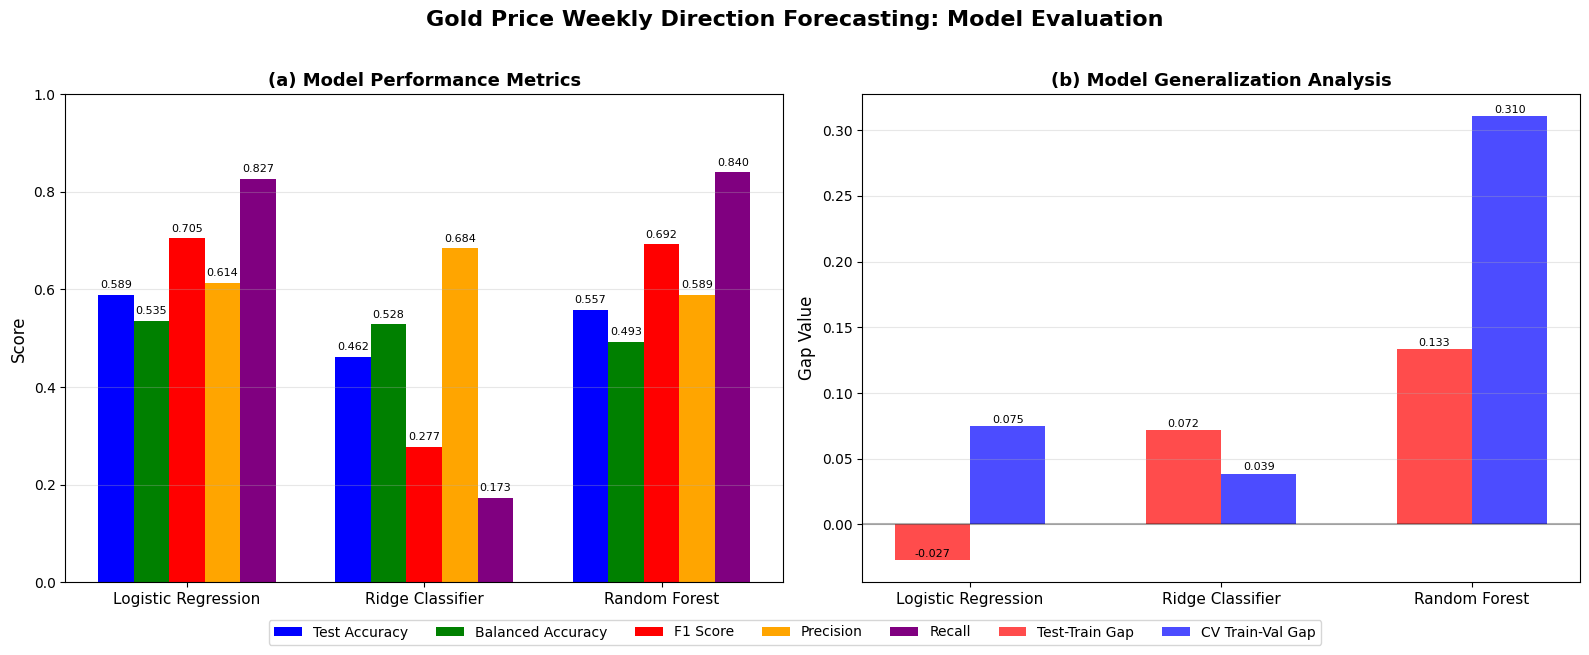

In [48]:
# Call the function:
fig = create_summary_chart(comparison_df)
plt.show()

In [46]:
def plot_feature_importance(df, features):

    """
    This function helps to compare feature importance across all three models.
    Shows only importance scores without direction information.

    Parameters: df : Dataframe containing model results.
                features : List of feature names.
    Returns: fig : Matplotlib figure object.
    """

    # To create a figure with three subplots, one for each model.
    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    fig.suptitle('Top 10 Most Important Features for Each Model\n(Gold Price Weekly Direction Prediction)',
                 fontsize=16, fontweight='bold', y=1.02)

    # To define which models to plot.
    models_to_plot = ['Logistic Regression', 'Ridge Classifier', 'Random Forest']

    # To use the same color for all bars (makes comparison easier).
    bar_color = 'steelblue'

    # To iterate through each model and create its feature importance plot.
    for idx, model_name in enumerate(models_to_plot):
        ax = axes[idx]

        # To check if the model exists in the results dictionary.
        if model_name in df:
            model_data = df[model_name]['results']

            # To check if feature importance data is available for this model.
            if 'feature_importance' in model_data and model_data['feature_importance'] is not None:
                feat_imp = model_data['feature_importance']

                # To extract top 10 most important features.
                top_features = feat_imp.head(10).copy()

                # To get importance values.
                # For linear models, use absolute coefficient values.
                if 'Abs_Coefficient' in feat_imp.columns:
                    importance_values = top_features['Abs_Coefficient'].values
                    score_type = 'Absolute Coefficient'
                else:
                    # For Random Forest, use importance scores.
                    importance_values = top_features['Importance'].values
                    score_type = 'Importance Score'

                # To create horizontal bars.
                bars = ax.barh(range(len(top_features)), importance_values,
                               color=bar_color, alpha=0.8)

                # To configure the y-axis with feature names.
                ax.set_yticks(range(len(top_features)))
                ax.set_yticklabels(top_features['Feature'].tolist(), fontsize=10)
                ax.invert_yaxis()  # To display highest importance at the top.

                # To set x-axis label.
                ax.set_xlabel(score_type, fontsize=11)

                # To add title for this subplot.
                ax.set_title(f'{model_name}', fontsize=13, fontweight='bold', pad=10)

                # To add grid lines for better readability.
                ax.grid(True, axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    save_plot("feature_importance")
    return fig

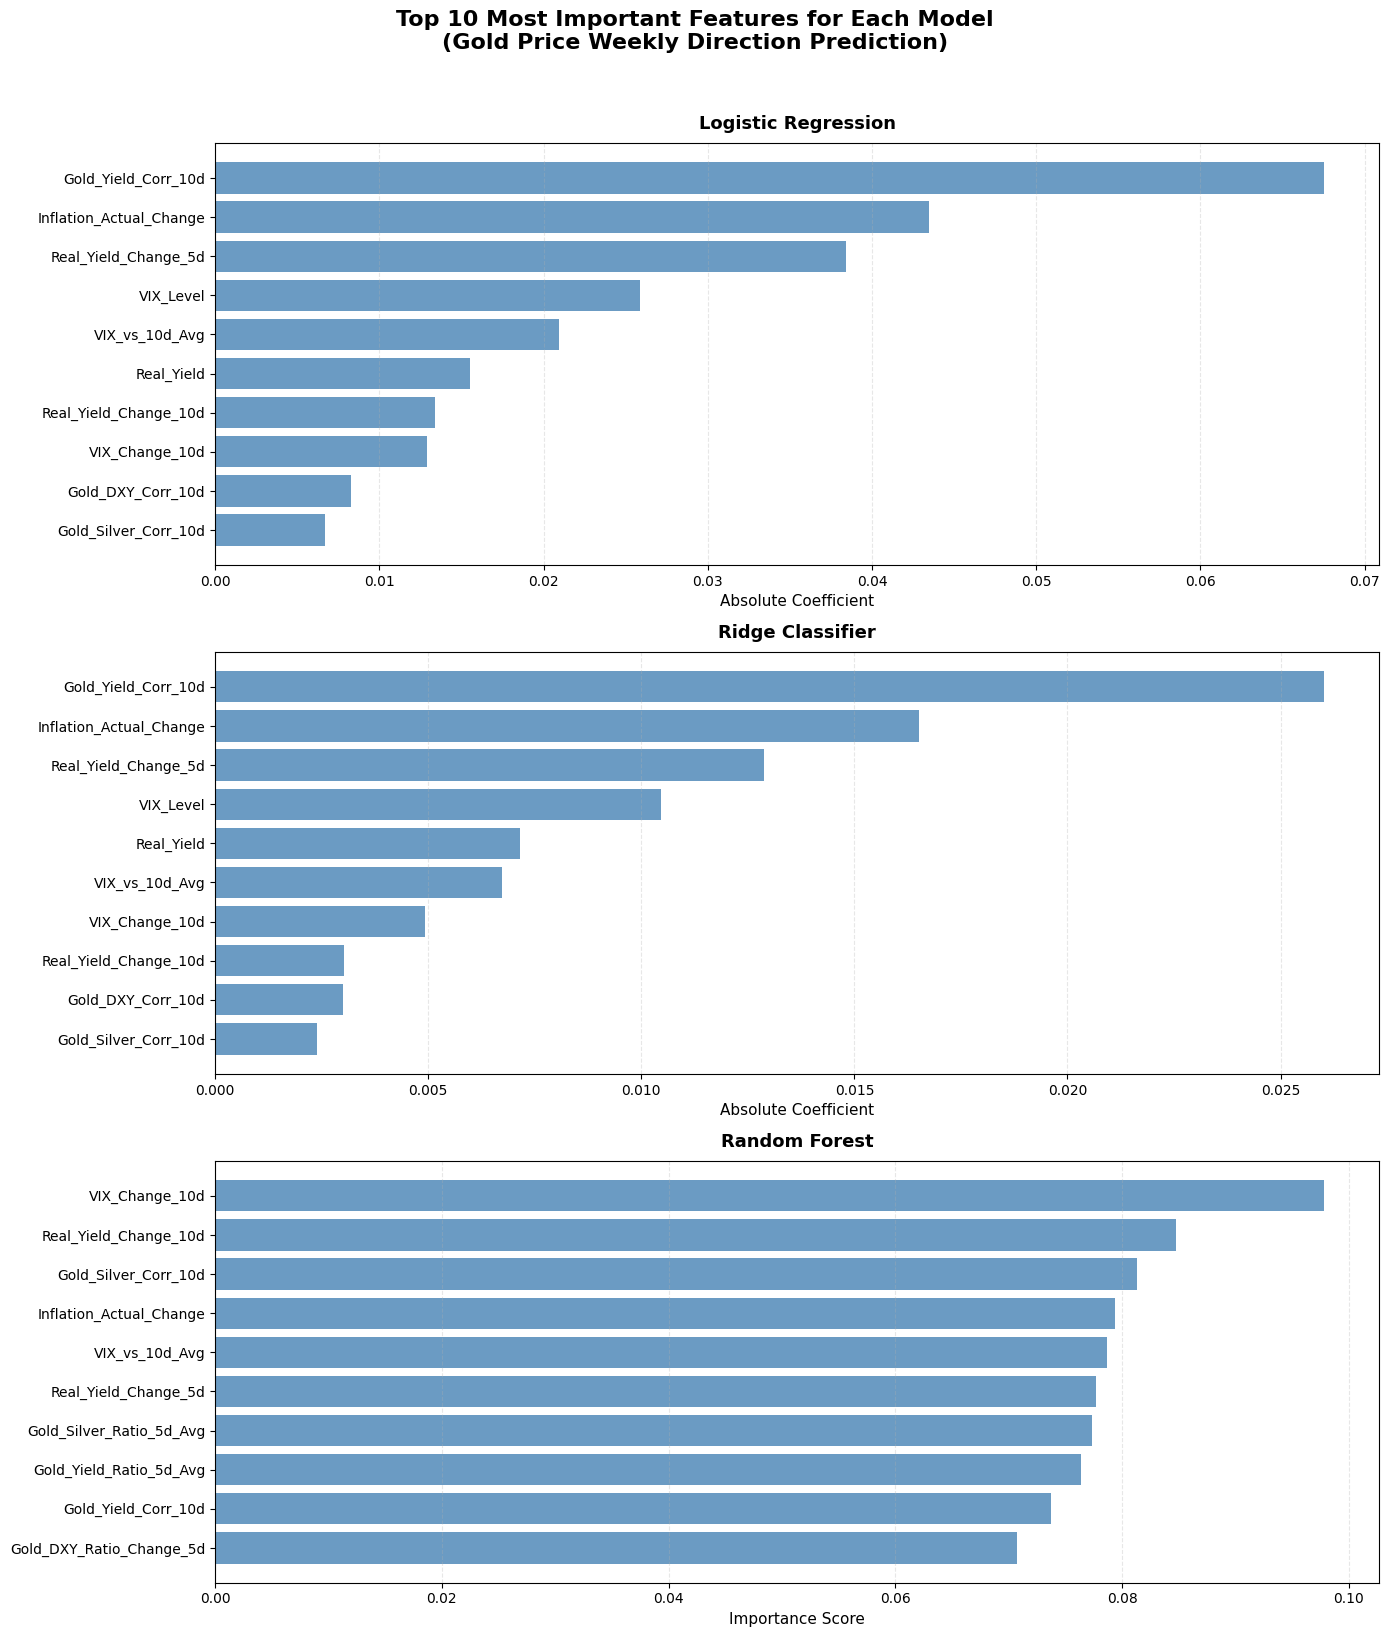

In [47]:
# To call the function.
fig = plot_feature_importance(results_dict, friday_features)
plt.show()